<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.0 MB/s eta 0:00:00


In [3]:
from fastai.vision.all import *
import timm

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

## Modelos

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')  
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

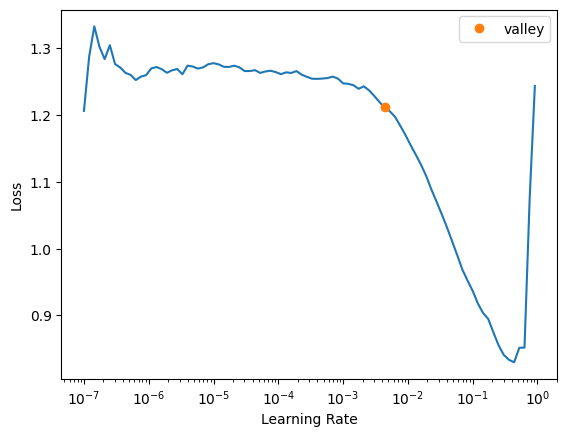

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


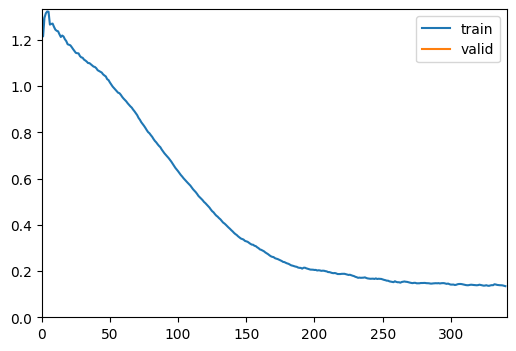

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


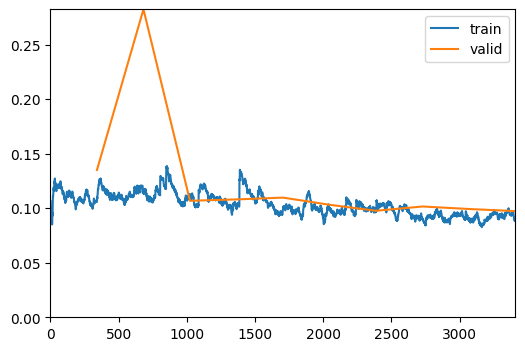

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.

### EfficientNet

Para que la ejecució quepa en la caché, hay que reducir los tamaños de las imágenes y el batch.

In [22]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [23]:
dls = db.dataloaders(imagesPath, bs=64)

In [24]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='efficientNetB3')  
]

In [25]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [25]:
import torch
torch.cuda.empty_cache()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.157429,0.123083,0.979527,0.000000,0.000000,0.000000,09:34


Better model found at epoch 0 with valid_loss value: 0.12308338284492493.


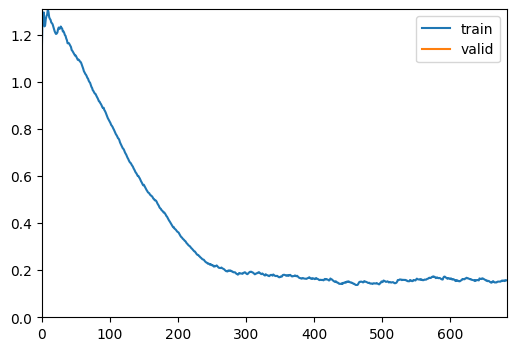

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.109194,0.098137,0.980441,0.000000,0.000000,0.000000,09:29
1,0.114298,0.099628,0.980441,0.000000,0.000000,0.000000,09:19
2,0.125833,0.099406,0.980441,0.000000,0.000000,0.000000,09:17
3,0.109041,0.095146,0.980441,0.000000,0.000000,0.000000,09:16
4,0.103849,0.098076,0.980441,0.000000,0.000000,0.000000,09:19
5,0.088844,0.095915,0.980441,0.000000,0.000000,0.000000,09:19
6,0.107047,nan,0.980441,0.000000,0.000000,0.000000,09:19
7,0.106938,nan,0.980441,0.000000,0.000000,0.000000,09:28
8,0.091529,0.092460,0.980441,0.000000,0.000000,0.000000,09:36
9,0.101932,0.092285,0.980441,0.000000,0.000000,0.000000,09:33


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09813690185546875.


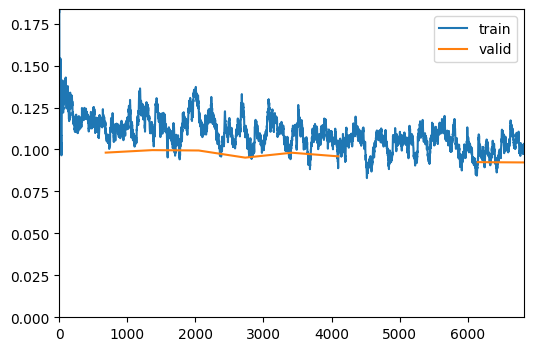

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09514576196670532.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Better model found at epoch 8 with valid_loss value: 0.09245970100164413.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 9 with valid_loss value: 0.09228470921516418.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 44 mins.

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='ConvNext')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:07<00:00, 45.9MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154840,0.114093,0.980258,0.000000,0.000000,0.000000,09:11


Better model found at epoch 0 with valid_loss value: 0.11409283429384232.


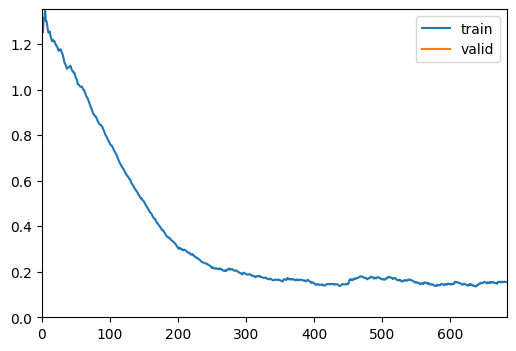

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.097386,0.097244,0.980441,0.000000,0.000000,0.000000,09:37
1,0.124461,0.116928,0.980441,0.000000,0.000000,0.000000,09:37
2,0.101866,0.100506,0.980441,0.000000,0.000000,0.000000,09:35
3,0.108117,0.091792,0.980441,0.000000,0.000000,0.000000,09:36
4,0.100571,0.094839,0.980441,0.000000,0.000000,0.000000,09:36
5,0.107470,0.090112,0.980441,0.000000,0.000000,0.000000,09:37
6,0.107873,0.088212,0.980898,0.857143,0.028037,0.054299,09:39
7,0.106709,0.086807,0.980532,0.538462,0.032710,0.061674,09:30
8,0.096510,0.085968,0.980898,0.857143,0.028037,0.054299,09:29
9,0.099173,0.086072,0.980623,0.600000,0.028037,0.053571,09:28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09724444150924683.


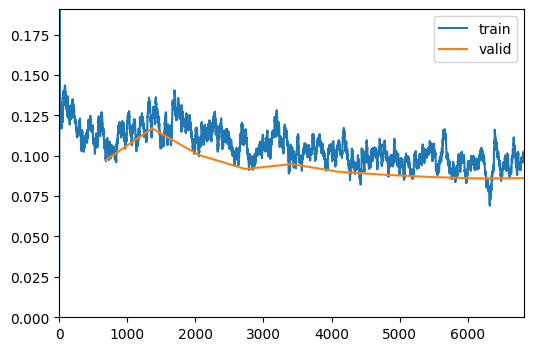

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09179195761680603.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.09011197090148926.
Better model found at epoch 6 with valid_loss value: 0.08821216225624084.
Better model found at epoch 7 with valid_loss value: 0.08680716902017593.
Better model found at epoch 8 with valid_loss value: 0.08596846461296082.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 45 mins.

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Hrnet')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-hrnet/hrnetv2_w44-c9ac8c18.pth" to /root/.cache/torch/hub/checkpoints/hrnetv2_w44-c9ac8c18.pth


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.144876,0.131406,0.976236,0.000000,0.000000,0.000000,12:44


Better model found at epoch 0 with valid_loss value: 0.13140591979026794.


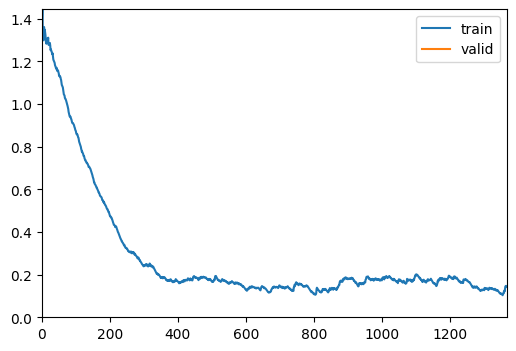

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099613,0.123273,0.976328,0.000000,0.000000,0.000000,14:00
1,0.126929,0.126066,0.976328,0.000000,0.000000,0.000000,14:00
2,0.118984,0.112464,0.976328,0.000000,0.000000,0.000000,14:10
3,0.114417,0.116200,0.976328,0.000000,0.000000,0.000000,13:59
4,0.103200,0.240522,0.974043,0.000000,0.000000,0.000000,13:58
5,0.095524,1.490318,0.974500,0.000000,0.000000,0.000000,13:55
6,0.101700,nan,0.976328,0.000000,0.000000,0.000000,13:54
7,0.073411,nan,0.976510,0.625000,0.019305,0.037453,13:52
8,0.094232,0.105128,0.976419,0.555556,0.019305,0.037313,13:52
9,0.097534,nan,0.976510,0.625000,0.019305,0.037453,13:50


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12327256053686142.


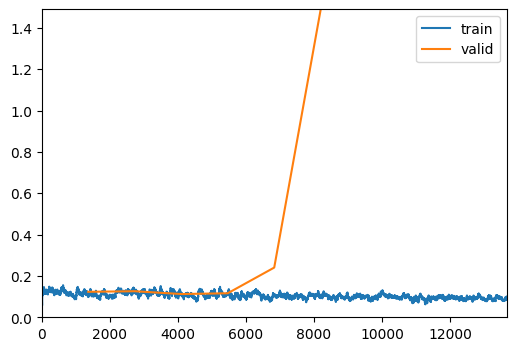

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11246427148580551.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 8 with valid_loss value: 0.10512750595808029.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

2 horas 33 minutos.

### Deit

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=8)

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h solo en la primera época, por lo que se espera que tarde 10 horas.

## Balanceo

In [6]:
df

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54701,1,9973,1729524723,R,MLO,43.0,0,0,0,1.0,0,C,49,False
54702,1,9989,63473691,L,MLO,60.0,0,0,0,NaN,0,C,216,False
54703,1,9989,1078943060,L,CC,60.0,0,0,0,NaN,0,C,216,False
54704,1,9989,398038886,R,MLO,60.0,0,0,0,0.0,0,C,216,True


In [7]:
tam = df.loc[df["cancer"] == 1]["patient_id"].unique().size

In [8]:
X = df.loc[::, df.columns.drop("cancer")].copy()
y = df.loc[::, "cancer"].copy()

In [9]:
y.value_counts()

0    53548
1     1158
Name: cancer, dtype: int64

Los datos están claramente desbalanceados. Se va a escoger al azar los elementos de la clase mayoritaria para entrenar a los modelos.

In [10]:
np.random.seed(0)
patients = np.random.choice(df.loc[df["cancer"] == 0]["patient_id"], tam)
patients = np.concatenate((patients, df.loc[df["cancer"] == 1]["patient_id"].unique()))
patients.size

972

In [11]:
dfb = df.loc[df["patient_id"].isin(patients)].copy()

In [12]:
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
87,1,10130,388811999,L,MLO,71.0,1,1,1,0.0,0,B,49,False
88,1,10130,613462606,L,CC,71.0,1,1,1,0.0,0,B,49,False
89,1,10130,1360338805,L,CC,71.0,1,1,1,0.0,0,B,49,False
90,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False
91,1,10130,1013166704,R,CC,71.0,0,0,0,NaN,0,B,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54598,2,9851,1945262248,R,MLO,58.0,0,0,0,NaN,0,NaN,48,False
54625,1,9894,564726178,L,CC,50.0,0,1,0,0.0,0,B,49,True
54626,1,9894,942623950,L,MLO,50.0,0,1,0,0.0,0,B,49,True
54627,1,9894,1991772614,R,CC,50.0,0,1,0,0.0,0,B,49,True


In [13]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    shutil.copytree(imagesPath/str(patient), p_under/str(patient), dirs_exist_ok=True)

## Modelos undersampling

In [14]:
def cadena2(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func2(fname):
    return dfb.loc[dfb['image_id'] == int(cadena2(fname.name))]['cancer'].values[0]

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 347MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.151652,0.842945,0.588428,0.282675,0.397436,0.330373,01:17


Better model found at epoch 0 with valid_loss value: 0.8429452180862427.


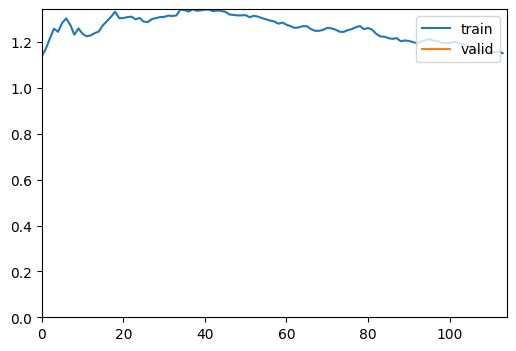

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.827866,0.650811,0.730349,0.348837,0.064103,0.108303,01:27
1,0.761209,0.624746,0.731441,0.250000,0.025641,0.046512,01:27
2,0.742217,0.645039,0.729258,0.250000,0.029915,0.053435,01:26
3,0.725854,0.678734,0.707424,0.242424,0.068376,0.106667,01:27
4,0.693442,0.599018,0.721616,0.352113,0.106838,0.163934,01:26
5,0.683520,0.630916,0.745633,0.538462,0.029915,0.056680,01:27
6,0.654430,0.540075,0.752183,0.537634,0.213675,0.305810,01:26
7,0.600882,0.540813,0.771834,0.790698,0.145299,0.245487,01:27
8,0.583713,0.651750,0.751092,0.875000,0.029915,0.057851,01:26
9,0.583468,0.513883,0.770742,0.662162,0.209402,0.318182,01:26


Better model found at epoch 0 with valid_loss value: 0.650810956954956.


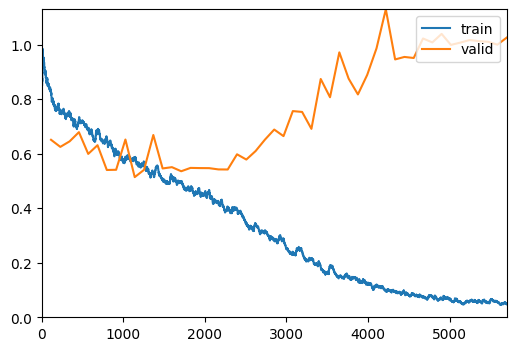

Better model found at epoch 1 with valid_loss value: 0.6247456669807434.
Better model found at epoch 4 with valid_loss value: 0.5990183353424072.
Better model found at epoch 6 with valid_loss value: 0.5400754809379578.
Better model found at epoch 9 with valid_loss value: 0.5138833522796631.


In [ ]:
learn.fine_tune(50, base_lr=1e-3)

Ha tardado 1h 15 mins.

### EfficientNet

In [32]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [33]:
dls = db.dataloaders(p_under, bs=16)

In [34]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='efficientNetB3')
]

In [35]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [36]:
learn.fine_tune(20, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


No sé por qué no funciona.

### ConvNext

In [15]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [16]:
dls = db.dataloaders(p_under, bs=16)

In [17]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='ConvNext')
]

In [18]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:01<00:00, 211MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.025238,0.643269,0.718341,0.360465,0.132479,0.193750,03:12


Better model found at epoch 0 with valid_loss value: 0.6432688236236572.


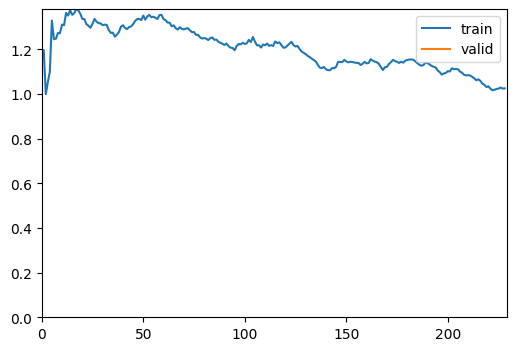

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.783032,0.576974,0.724891,0.392857,0.141026,0.207547,04:03
1,0.730277,0.574237,0.728166,0.407407,0.141026,0.209524,04:02
2,0.743283,0.567021,0.723799,0.385542,0.136752,0.201893,04:02


Better model found at epoch 0 with valid_loss value: 0.5769740343093872.


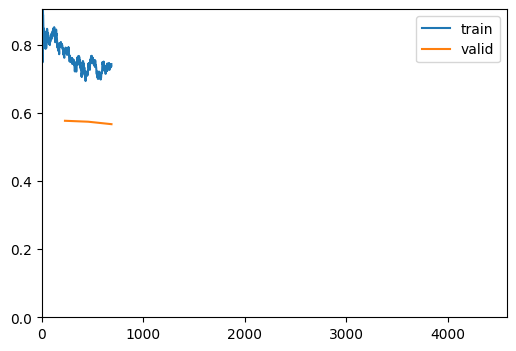

Better model found at epoch 1 with valid_loss value: 0.5742368698120117.
Better model found at epoch 2 with valid_loss value: 0.5670210123062134.


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.783032,0.576974,0.724891,0.392857,0.141026,0.207547,04:03
1,0.730277,0.574237,0.728166,0.407407,0.141026,0.209524,04:02
2,0.743283,0.567021,0.723799,0.385542,0.136752,0.201893,04:02
3,0.710465,0.586157,0.740175,0.441176,0.064103,0.111940,04:02
4,0.645177,0.584288,0.718341,0.382353,0.166667,0.232143,04:01
5,0.611573,0.561376,0.747817,0.545455,0.076923,0.134831,04:01
6,0.587096,0.533610,0.753275,0.550000,0.188034,0.280255,04:01
7,0.590450,0.516909,0.747817,0.519481,0.170940,0.257235,04:00
8,0.541260,0.517608,0.763100,0.626866,0.179487,0.279070,04:00
9,0.553833,0.507528,0.751092,0.536585,0.188034,0.278481,04:01


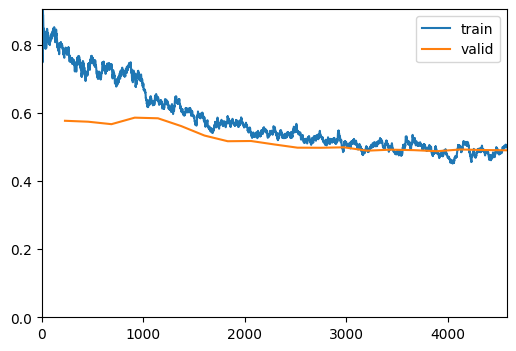

Better model found at epoch 5 with valid_loss value: 0.5613764524459839.
Better model found at epoch 6 with valid_loss value: 0.5336103439331055.
Better model found at epoch 7 with valid_loss value: 0.5169093608856201.
Better model found at epoch 9 with valid_loss value: 0.507527768611908.
Better model found at epoch 10 with valid_loss value: 0.4979976713657379.
Better model found at epoch 11 with valid_loss value: 0.4977230727672577.
Better model found at epoch 13 with valid_loss value: 0.48917579650878906.
Better model found at epoch 16 with valid_loss value: 0.48765039443969727.


In [19]:
learn.fine_tune(20, base_lr=1e-3)

Ha tardado 1 hora y 5 minutos.

### Hrnet

In [20]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [21]:
dls = db.dataloaders(p_under, bs=32)

In [22]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='Hrnet')
]

In [23]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [24]:
learn.fine_tune(20, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


OutOfMemoryError: ignored

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(20, base_lr=1e-3)